# 12 Decoder

**Cross Attention:** $\quad$ $\operatorname{CrossAttention}(X,Y)=\operatorname{MultiHead}(Y,X,X)$

**Masking:** $\;$ introduce a mask $\,M\in\{0,1\}^{n\times n}\,$ of scores to ignore (with $0$)
$$\operatorname{AttentionWeights}(Q,K,M)%
=\operatorname{Softmax}\left(\tfrac{1}{\sqrt{d_{\text{k}}}}QK^t\odot M\right)\in\mathbb{R}^{n\times n}$$

**Causal Masking:** $\;$ cancels attention weights for output queries not yet generated

In [1]:
def create_causal_mask(size):
    "Mask out subsequent positions to preserve the auto-regressive property."
    attn_shape = (1, size, size); causal_mask = torch.triu(torch.ones(attn_shape), diagonal=1).type(torch.uint8)
    return causal_mask == 0

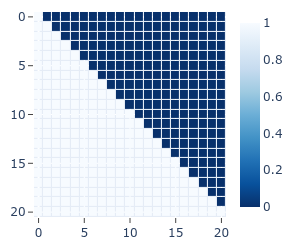

In [2]:
import torch; import plotly.graph_objects as go; n = 21; matrix = create_causal_mask(n).int().numpy()[0]
heat = go.Heatmap(z=matrix, xgap=1.1, ygap=1.1, colorscale='Blues_r', colorbar_thickness=20, colorbar_ticklen=3)
layout = go.Layout(width=300, height=250, yaxis_autorange='reversed', xaxis=dict(ticks='outside'), 
    yaxis=dict(ticks='outside'), margin=dict(l=10,r=10,t=10,b=10))
fig=go.Figure(data=[heat], layout=layout); fig.show(renderer="png", width=300, height=250)


<p style="page-break-after:always;"></p>


**Decoder Layer:** $\;$ given an input (to the decoder) $\,X,\,$ output $\,Y=Y^{(1)}\,$ and causal mask $\,M,\,$ applies$$\begin{align*}
Y^{(2)}&=\operatorname{LayerNorm}(Y^{(1)})            &Y^{(8)}&=\operatorname{Dropout}(Y^{(7)})\\
Y^{(3)}&=\operatorname{SelfAttention}(Y^{(2)}, M)     &Y^{(9)}&=\operatorname{Add}(Y^{(5)},Y^{(8)})\\
Y^{(4)}&=\operatorname{Dropout}(Y^{(3)})              &Y^{(10)}&=\operatorname{LayerNorm}(Y^{(9)})\\
Y^{(5)}&=\operatorname{Add}(Y^{(1)},Y^{(4)})          &Y^{(11)}&=\operatorname{PWFFN}(Y^{(10)})\\
Y^{(6)}&=\operatorname{LayerNorm}(Y^{(5)})            &Y^{(12)}&=\operatorname{Dropout}(Y^{(10)})\\
Y^{(7)}&=\operatorname{CrossAttention}(X,Y^{(6)})     &Y^{(13)}&=\operatorname{Add}(Y^{(9)},Y^{(12)})
\end{align*}$$
$$\operatorname{DecoderLayer}(X, Y, M)=Y^{(13)}$$

**Pre-norm vs post-norm:** $\;$ LayerNorm first (pre-norm; above) or after Add (post-norm; original version)

**Decoder:** $\;$ given an input $\,X,\,$ output $\,Y\,$ and mask $\,M,\,$ applies a stack of $N=6$ identical decoder layers
$$\begin{align*}
Y^{(2)}&=\operatorname{DecoderLayer}(X, Y^{(1)}, M)\\
Y^{(3)}&=\operatorname{DecoderLayer}(X, Y^{(2)}, M)\\
\vdots\\
Y^{(N+1)}&=\operatorname{DecoderLayer}(X, Y^{(N)}, M)\\
\operatorname{Decoder}(X, Y, M)&=\operatorname{LayerNorm}(Y^{(N+1)})
\end{align*}$$



<p style="page-break-after:always;"></p>


**Example:** $\;$ $\operatorname{Decoder}(X, Y, M)\,$ of a single layer with the input seen above and initial output

In [3]:
import torch; import torch.nn as nn; torch.manual_seed(23)
import import_ipynb; from at251 import create_model
model = create_model(src_vocab_size=3, tgt_vocab_size=3, embed_dim=2, num_layers=1, num_heads=1, dropout=0.)
src = torch.LongTensor([[1, 2, 1]]); src_mask = torch.ones(1, 1, 3) # None funciona igual (sin padding)
ys = torch.zeros(1, 1).type_as(src); tgt_mask = create_causal_mask(ys.size(1)).type_as(src.data)
print("src =", src, "src_mask =", src_mask, "ys =", ys, "tgt_mask =", tgt_mask)
x1 = model.encode(src, None).data; print("x1 =", str(x1).replace('\n',''))
y1 = model.tgt_embed(ys).data; print("y1 =", y1)
y2 = model.decoder.layers[0].norm_self_attn(y1).data; print("y2 =", y2)
y3 = model.decoder.layers[0].self_attn(y2, y2, y2, tgt_mask).data; print("y3 =", y3)
y4 = model.decoder.layers[0].dropout(y3).data; print("y4 =", y4)
y5 = y1 + y4; print("y5 =", y5)
y6 = model.decoder.layers[0].norm_cross_attn(y5).data; print("y6 =", y6)
y7 = model.decoder.layers[0].cross_attn(y6, x1, x1, None).data; print("y7 =", y7)
y8 = model.decoder.layers[0].dropout(y7).data; print("y8 =", y8)
y9 = y5 + y8; print("y9 =", y9)
y10 = model.decoder.layers[0].norm_ff(y9).data; print("y10 =", y10)
y11 = model.decoder.layers[0].ff(y10).data; print("y11 =", y11)
y12 = model.decoder.layers[0].dropout(y11).data; print("y12 =", y12)
y13 = y9 + y12; print("y13 =", y13)
print(model.decoder.layers[0](y1, x1, None, tgt_mask).data)
print(model.decoder.norm(y13).data, model.decode(ys, x1, None, tgt_mask).data)

src = tensor([[1, 2, 1]]) src_mask = tensor([[[1., 1., 1.]]]) ys = tensor([[0]]) tgt_mask = tensor([[[1]]])
x1 = tensor([[[-0.7071,  0.7071],         [ 0.7071, -0.7071],         [ 0.7071, -0.7071]]])
y1 = tensor([[[1.3548, 1.4321]]])
y2 = tensor([[[-0.7070,  0.7070]]])
y3 = tensor([[[-0.7602, -0.0424]]])
y4 = tensor([[[-0.7602, -0.0424]]])
y5 = tensor([[[0.5946, 1.3897]]])
y6 = tensor([[[-0.7071,  0.7071]]])
y7 = tensor([[[0.9877, 1.1094]]])
y8 = tensor([[[0.9877, 1.1094]]])
y9 = tensor([[[1.5823, 2.4991]]])
y10 = tensor([[[-0.7071,  0.7071]]])
y11 = tensor([[[0.8719, 1.1273]]])
y12 = tensor([[[0.8719, 1.1273]]])
y13 = tensor([[[2.4542, 3.6264]]])
tensor([[[2.4542, 3.6264]]])
tensor([[[-0.7071,  0.7071]]]) tensor([[[-0.7071,  0.7071]]])



<p style="page-break-after:always;"></p>
